# _Drake vs Kendrick Rhyme Scheme Analysis pt. 2_

How does lyrical complexity in hip hop relate to fan sentiment and engagement in online communities, specifically on Reddit and YouTube? On top of this, can I apply more metrics to draw deeper conclusions relating to the artist's songs?

I will look at Drake and Kendrick Lamar, reusing rhyme metrics from Project 1 and adding a few simple new lyrical complexity metrics (syllables per line, stress patterns).

In [ ]:
!pip install google-api-python-client
!pip install emoji

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import nltk
from nltk.corpus import cmudict
nltk.download("cmudict") # dictionary for rhyme scheme analysis
from dotenv import load_dotenv
import requests
import re
import sqlite3
from googleapiclient.discovery import build
import urllib.parse
from googleapiclient.errors import HttpError # debug yt error
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")

[nltk_data] Downloading package cmudict to
[nltk_data]     /Users/mattabatangle/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/mattabatangle/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
load_dotenv("3510.env")

True

I am going to get started by creating my sqlite DB.

In [3]:
dbConnection = sqlite3.connect("Project2.db")
curse = dbConnection.cursor()

In [4]:
# table for lyric metrics per song
curse.execute("""
    CREATE TABLE IF NOT EXISTS 'songs' (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        song_title TEXT NOT NULL,
        artist TEXT NOT NULL,
        album TEXT,
        rhyme_density REAL,
        rhyme_scheme_variety REAL,
        internal_rhyme_rate REAL,
        avg_syllables_per_line REAL,
        syllable_variance REAL,
        stress_variability REAL,
        word_count INTEGER,
        complexity REAL
    );""")

In [5]:
# table for reddit posts and comments
curse.execute("""
    CREATE TABLE IF NOT EXISTS reddit_posts (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        reddit_id TEXT UNIQUE,
        author TEXT,
        subreddit TEXT,
        published_at TEXT,
        score INTEGER,
        text TEXT,
        artist_tag TEXT,
        sentiment REAL
    );""")

In [6]:
# table for YouTube comments
curse.execute("""
    CREATE TABLE IF NOT EXISTS youtube_comments (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        comment_id TEXT UNIQUE,
        author TEXT,
        video_id TEXT,
        published_at TEXT,
        like_count INTEGER,
        text TEXT,
        artist_tag TEXT,
        sentiment REAL
    );""")

In [7]:
dbConnection.commit()

In [8]:
songDF = pd.read_csv("Project2Data.csv") # load in data from project 1
# (I just added one line at the bottom of project 1 saving these specific columns)
songDF.head()

,track_name,artist,album_name,word_count,rhyme_density,complexity
0,tv off (feat. lefty gunplay),Kendrick Lamar,GNX,770,0.929504,715.718016
1,HUMBLE.,Kendrick Lamar,DAMN.,598,0.892562,533.752066
2,Swimming Pools (Drank),Kendrick Lamar,Swimming Pools (Drank),859,0.928654,797.713464
3,LOVE. FEAT. ZACARI.,Kendrick Lamar,DAMN.,488,0.947242,462.254197
4,PRIDE.,Kendrick Lamar,DAMN.,504,0.880626,443.835616


In [9]:
# add song data from projec 1 to sqlite db
for i, row in songDF.iterrows():
        curse.execute("""
        INSERT INTO songs (
            song_title,
            artist,
            album,
            avg_syllables_per_line,
            syllable_variance,
            stress_variability,
            word_count,
            rhyme_density,
            complexity
        )
        VALUES (?, ?, ?, NULL, NULL, NULL, ?, ?, ?); 
    """, (
        row["track_name"],
        row["artist"],
        row["album_name"],
        row["word_count"],
        row["rhyme_density"],
        row["complexity"]
    )) # right now I am using NULL as a placeholder for all the values I will calculate later in this project

In [10]:
dbConnection.commit()

Next, I want to add a few more stats and go a little deeper with the lyrics (hinted at above)

In [11]:
lyricsDF = pd.read_csv("project2Lyrics.csv") # load in lyrics from project 1

In [12]:
lyricsDF.head()

,track_name,artist,lyrics
0,tv off (feat. lefty gunplay),Kendrick Lamar,All I ever wanted was a black Grand National\n...
1,HUMBLE.,Kendrick Lamar,Nobody pray for me\nIt been that day for me\nW...
2,Swimming Pools (Drank),Kendrick Lamar,"Pour up (Drank), head shot (Drank)\nSit down (..."
3,LOVE. FEAT. ZACARI.,Kendrick Lamar,"Maldición, amor o lujuria\nMaldición, todos no..."
4,PRIDE.,Kendrick Lamar,Love's gonna get you killed\nBut pride’s gonna...


First, I want to set up CMU dict again and set up syllable counting with a fallback in case the word is not present in the CMU Dict

In [13]:
cmu = cmudict.dict()

In [14]:
def get_cmu_pronunciations(word): # return list of pronunciations from CMU
    word = word.lower()
    return cmu.get(word, []) # or empty list if missing

In [15]:
def count_syllables_from_cmu(pron): # count syllables in one CMU pronunciation
    count = 0 
    for phone in pron: # loop over phonemes in pronunciation
        if any(char.isdigit() for char in phone): # check if any character in the phone is a stress digit
            count += 1 # count it
    return count

In [16]:
def estimate_syllables_fallback(word): # if word not in dict (highly unlikely)
    word = word.lower() # lower
    word = re.sub(r"[^a-z]", "", word) # remove punctuation
    if not word: 
        return 0
    groups = re.findall(r"[aeiouy]+", word) # counting vowel groups
    return max(1, len(groups)) # 1 in case word has no vowels

In [17]:
def count_syllables_in_word(word):
    prons = get_cmu_pronunciations(word) # earlier function
    if prons:
        # use first pronunciation
        return count_syllables_from_cmu(prons[0])
    else:
        return estimate_syllables_fallback(word)

Next, I want to look at stress and variability in wording. This is the closest I can get to rhythmic density with just lyrics.

In [18]:
def get_stress_sequence_for_line(line): # return a list of stress digits (0,1,2) for all syllables in the line
    stresses = [] # list
    words = re.findall(r"[A-Za-z']+", line) # extract words
    for w in words:
        prons = get_cmu_pronunciations(w) # call earlier function
        if not prons:
            continue # if CMU has no entry, skip the word entirely
        pron = prons[0] 
        for phone in pron:
            # phones with digits are vowels with stress markers (used last vowel in word for rhyme in last project)
            digits = [char for char in phone if char.isdigit()] # extract num from phone
            if digits: # check phone has digit
                stresses.append(int(digits[0]))
    return stresses

In [19]:
def compute_stress_variability(stress_seq): # Compute fraction of syllable pairs that switch stress
    if len(stress_seq) < 2:
        return 0.0 # cannot measure variation with fewer than two syllables
    changes = 0 # counter for stress changes
    for i in range(1, len(stress_seq)): # check if the current stress differs from the previous one
        if stress_seq[i] != stress_seq[i - 1]:
            changes += 1
    # The denominator is the number of syllable pairs (no matter if it switched or not)
    return changes / (len(stress_seq) - 1)

Ok, now I am going to combine the previous too sections of functions into one giant function to clean things up.

In [20]:
def compute_line_metrics(lyrics_text): # compute above metrics for input lyrics
    lines = [ln.strip() for ln in lyrics_text.split("\n")] # split on new line char and strip
    # keep only non empty lines with at least one letter (real lines)
    lines = [ln for ln in lines if re.search(r"[A-Za-z]", ln)]
    
    if not lines:
        return 0.0, 0.0, 0.0
    
    syllable_counts = []
    all_stresses = []
    
    for line in lines: # line by line
        words = re.findall(r"[A-Za-z']+", line) # extract words
        if not words:
            continue # just skip
        
        # syllables
        syllables_in_line = sum(count_syllables_in_word(w) for w in words) # total syllables per line using prev function
        syllable_counts.append(syllables_in_line) # add to total count
        
        # stress pattern for this line
        stresses = get_stress_sequence_for_line(line) # call prev function
        all_stresses.extend(stresses) # add list to list
    
    if not syllable_counts: # if somehow it never got any syllable counts, return zeros
        avg_syll = 0.0
        var_syll = 0.0
    else:
        # compute the average number of syllables per line
        avg_syll = float(np.mean(syllable_counts))
        # compute the variance in syllables per line
        var_syll = float(np.var(syllable_counts)) # higher variance means some lines are much longer than others (further from mean)
    
    stress_var = compute_stress_variability(all_stresses) # over whole song

    return avg_syll, var_syll, stress_var

Time to perform and add these calculations to the DB

In [21]:
for i, row in lyricsDF.iterrows(): # iterat through and assign new vals
    title = row["track_name"]
    artist = row["artist"]
    lyrics_text = row["lyrics"]
    
    avg_syll, var_syll, stress_var = compute_line_metrics(lyrics_text)
    
    curse.execute("""
        UPDATE songs
        SET avg_syllables_per_line = ?,
            syllable_variance = ?,
            stress_variability = ?
        WHERE song_title = ? AND artist = ?;
    """, (avg_syll, var_syll, stress_var, title, artist))

In [22]:
dbConnection.commit()

Due to Reddit API restrictions I focused the community analysis on YouTube.

In [23]:
# I am going to remove the reddit table here instead of deleting the initial table creation just for effect
curse.execute("DROP TABLE IF EXISTS reddit_posts;")
dbConnection.commit()

In [24]:
ytKey = os.getenv("YOUTUBE_KEY")

In [25]:
# API setup
youtube = build("youtube", "v3", developerKey=ytKey)

Start by searching for the best video for a song

In [26]:
def search_video_for_song(artist, track_name, max_results=1): # simple call to API using artist
    query = f"{artist} {track_name} official audio"
    
    request = youtube.search().list(part="snippet",q=query, type="video", maxResults=max_results)
    response = request.execute()
    
    items = response.get("items", [])
    if not items:
        return None
    
    # take first result
    video_id = items[0]["id"]["videoId"]
    return video_id

In [27]:
curse.execute("SELECT song_title, artist FROM songs LIMIT 1;")
song_title, artist = curse.fetchone()

In [28]:
print("Testing:", artist, "-", song_title)
print("Video ID:", search_video_for_song(artist, song_title))

Testing: Kendrick Lamar - tv off (feat. lefty gunplay)
Video ID: U8F5G5wR1mk


If you search the ID on youtube the first result SHOULD be the song (was for me).

In [29]:
def insert_youtube_comment(comment_id, author, video_id, published_at, like_count, text, artist_tag): # define insertion func for later
    curse.execute("""
        INSERT OR IGNORE INTO youtube_comments (
            comment_id,
            author,
            video_id,
            published_at,
            like_count,
            text,
            artist_tag,
            sentiment
        ) VALUES (?, ?, ?, ?, ?, ?, ?, NULL);""", # sentiment will be filled in after I do VADER analysis
                (comment_id, author, video_id, published_at, like_count, text, artist_tag))

Next I want to actually scrape the comment data.

In [30]:
def fetch_comments_for_video(video_id, artist_tag, max_comments=200):
    fetched = 0 # counting how many saved comments
    next_page_token = None # used for iteration through yt page results (param)

    while fetched < max_comments: # not maxed out
        remaining = max_comments - fetched
        page_size = min(100, remaining) # whichever lower
        # req taking in comment snippet
        request = youtube.commentThreads().list(part="snippet", videoId=video_id, maxResults=page_size, textFormat="plainText", pageToken=next_page_token)
        
        try: # added in later debug 
            response = request.execute()

        except HttpError as e:
            # if the video has comments disabled (added this later due to comments being disabled)
            if e.resp.status == 403 and "commentsDisabled" in str(e):
                print(f"Comments disabled for video {video_id}. Skipping.")
                return 0 # nothing fetched
            # otherwise rethrow
            raise e

        for item in response['items']:
            snippet = item['snippet']['topLevelComment']['snippet'] # take comment snippet

            comment_id = item['id']
            author = snippet.get('authorDisplayName')
            text = snippet.get('textOriginal', '') # default blank
            like_count = snippet.get('likeCount', 0) # default 0
            published_at = snippet.get('publishedAt')
            # call prev function to insert into the DB
            insert_youtube_comment(comment_id=comment_id, author=author, video_id=video_id, published_at=published_at, like_count=like_count, text=text, artist_tag=artist_tag)

            fetched += 1 # count comment saved
            if fetched >= max_comments: # if max: quit
                break

        next_page_token = response.get("nextPageToken") # next page (similar to how Spotify API works with pages)
        if not next_page_token: # if no more pages (no more comments) break
            break

    dbConnection.commit()
    print(f"Fetched {fetched} comments for video {video_id} ({artist_tag})")

Since this is going to be a ton of data I want to test it with two songs first

In [31]:
curse.execute("""
    SELECT song_title, artist
    FROM songs
    WHERE artist = 'Drake'
    LIMIT 1;""")
drake_songs = curse.fetchall()
curse.execute("""
    SELECT song_title, artist
    FROM songs
    WHERE artist = 'Kendrick Lamar'
    LIMIT 1;""")
kendrick_songs = curse.fetchall()
print(drake_songs, kendrick_songs)

[('One Dance', 'Drake')] [('tv off (feat. lefty gunplay)', 'Kendrick Lamar')]


In [32]:
for title, artist in drake_songs + kendrick_songs: # only two for test
    print(f"Processing: {artist} - {title}")
    video_id = search_video_for_song(artist, title)
    if not video_id:
        print("No video found, skipping.")
        continue # same as how I did it with Spotify API -- skip if no result
        
    print("Found video:", video_id)
    fetch_comments_for_video(video_id=video_id, artist_tag=artist,max_comments=100) # safe for testing

Processing: Drake - One Dance
Found video: FOqKN-ouAUE
Fetched 100 comments for video FOqKN-ouAUE (Drake)
Processing: Kendrick Lamar - tv off (feat. lefty gunplay)
Found video: U8F5G5wR1mk
Fetched 100 comments for video U8F5G5wR1mk (Kendrick Lamar)


In [33]:
curse.execute("""
    SELECT artist_tag, COUNT(*) 
    FROM youtube_comments
    GROUP BY artist_tag;""")
print(curse.fetchall())

[('Drake', 100), ('Kendrick Lamar', 100)]


In [34]:
len(songDF[songDF["artist"] == "Drake"])

34

In [35]:
len(songDF[songDF["artist"] == "Kendrick Lamar"])

23

Need the above numbers to know limit in SQL query.

In [36]:
curse.execute("""
    SELECT song_title, artist
    FROM songs
    WHERE artist = 'Drake'
    LIMIT 34;""")
drake_songs = curse.fetchall()
curse.execute("""
    SELECT song_title, artist
    FROM songs
    WHERE artist = 'Kendrick Lamar'
    LIMIT 23;""")
kendrick_songs = curse.fetchall()

In [37]:
for title, artist in drake_songs + kendrick_songs:
    print(f"Processing: {artist} - {title}")
    video_id = search_video_for_song(artist, title)
    if not video_id:
        print("No video found, skipping.")
        continue # same as how I did it with Spotify API -- skip if no result

    print("Found video:", video_id)
    fetch_comments_for_video(video_id, artist_tag=artist, max_comments=200) # 200 is enough for good stats

Processing: Drake - One Dance
Found video: ki0Ocze98U8
Fetched 200 comments for video ki0Ocze98U8 (Drake)
Processing: Drake - Passionfruit
Found video: EgfsXTOn_pI
Comments disabled for video EgfsXTOn_pI. Skipping.
Processing: Drake - Headlines
Found video: Sn3SUnL44w4
Comments disabled for video Sn3SUnL44w4. Skipping.
Processing: Drake - Not You Too (feat. Chris Brown)
Found video: ZX_mvoY_Hg0
Fetched 200 comments for video ZX_mvoY_Hg0 (Drake)
Processing: Drake - NOKIA
Found video: RDH71p3LgWM
Comments disabled for video RDH71p3LgWM. Skipping.
Processing: Drake - God's Plan
Found video: m1a_GqJf02M
Comments disabled for video m1a_GqJf02M. Skipping.
Processing: Drake - Which One (feat. Central Cee)
Found video: 9-dEHfSCZUQ
Comments disabled for video 9-dEHfSCZUQ. Skipping.
Processing: Drake - Teenage Fever
Found video: e8HtwsnuTIw
Comments disabled for video e8HtwsnuTIw. Skipping.
Processing: Drake - DIE TRYING
Found video: CiV9BHZCaKQ
Fetched 200 comments for video CiV9BHZCaKQ (Drake)

Looks like there are a ton of different reasons Youtube API blocks comments (record labels, stricter guidlines with API, etc.)

On the bright side I think this is enough data to continue on

In [38]:
# bring in comments to pandas df
commentsDF = pd.read_sql_query("SELECT * FROM youtube_comments", dbConnection)
commentsDF.head()

,id,comment_id,author,video_id,published_at,like_count,text,artist_tag,sentiment
0,1,UgxC9OkGPPrsmUZslKB4AaABAg,@jilliannotice8852,FOqKN-ouAUE,2025-12-10T16:53:16Z,0,My thing is when they send me to abcd for help...,Drake,None
1,2,UgxjWZNe1TI43Y1h-7t4AaABAg,@9020966883,FOqKN-ouAUE,2025-12-10T11:02:35Z,0,1:35 is the best part,Drake,None
2,3,UgwNeYsUTWE9nab-Wst4AaABAg,@notzy0,FOqKN-ouAUE,2025-12-09T13:20:22Z,10,i forgot this song exists😭😭,Drake,None
3,4,Ugwtp60ApYzhdlEN6ah4AaABAg,@AlexaVargasHolayomellamoAlexaG,FOqKN-ouAUE,2025-12-05T20:23:24Z,0,mais❤❤❤❤❤❤❤❤❤❤❤mo\nAsd,Drake,None
4,5,UgxH7eK0OxynQYVwjBl4AaABAg,@fatimaammarjaffery1774,FOqKN-ouAUE,2025-12-04T18:04:41Z,8,This song hits differently in 2025\n\nWho agre...,Drake,None


In [39]:
vaderSIA = SentimentIntensityAnalyzer()

In [40]:
def compute_sentiment(text): # quick function (same use as class)
    return vaderSIA.polarity_scores(text)['compound']

In [41]:
commentsDF['sentiment'] = commentsDF['text'].apply(compute_sentiment) # add in sentiment

Now I am going to save these back to the DB

In [42]:
for i, row in commentsDF.iterrows():
    curse.execute("""
        UPDATE youtube_comments
        SET sentiment = ?
        WHERE id = ?""", 
                  (row['sentiment'], row['id'])) # use key

In [43]:
dbConnection.commit()

In [44]:
# writing over both as this will be the data I work with from here
songDF = pd.read_sql_query("SELECT * FROM songs", dbConnection)
commentsDF = pd.read_sql_query("SELECT * FROM youtube_comments", dbConnection)

In [45]:
songDF.head()

,id,song_title,artist,album,rhyme_density,rhyme_scheme_variety,internal_rhyme_rate,avg_syllables_per_line,syllable_variance,stress_variability,word_count,complexity
0,1,tv off (feat. lefty gunplay),Kendrick Lamar,GNX,0.929504,None,None,11.415730,14.804696,0.442571,770,715.718016
1,2,HUMBLE.,Kendrick Lamar,DAMN.,0.892562,None,None,10.507463,11.115616,0.288854,598,533.752066
2,3,Swimming Pools (Drank),Kendrick Lamar,Swimming Pools (Drank),0.928654,None,None,10.928571,24.535714,0.416582,859,797.713464
3,4,LOVE. FEAT. ZACARI.,Kendrick Lamar,DAMN.,0.947242,None,None,11.329268,23.415973,0.466321,488,462.254197
4,5,PRIDE.,Kendrick Lamar,DAMN.,0.880626,None,None,10.754098,15.169041,0.497682,504,443.835616


In [46]:
commentsDF.head()

,id,comment_id,author,video_id,published_at,like_count,text,artist_tag,sentiment
0,1,UgxC9OkGPPrsmUZslKB4AaABAg,@jilliannotice8852,FOqKN-ouAUE,2025-12-10T16:53:16Z,0,My thing is when they send me to abcd for help...,Drake,0.2023
1,2,UgxjWZNe1TI43Y1h-7t4AaABAg,@9020966883,FOqKN-ouAUE,2025-12-10T11:02:35Z,0,1:35 is the best part,Drake,0.6369
2,3,UgwNeYsUTWE9nab-Wst4AaABAg,@notzy0,FOqKN-ouAUE,2025-12-09T13:20:22Z,10,i forgot this song exists😭😭,Drake,0.0000
3,4,Ugwtp60ApYzhdlEN6ah4AaABAg,@AlexaVargasHolayomellamoAlexaG,FOqKN-ouAUE,2025-12-05T20:23:24Z,0,mais❤❤❤❤❤❤❤❤❤❤❤mo\nAsd,Drake,0.0000
4,5,UgxH7eK0OxynQYVwjBl4AaABAg,@fatimaammarjaffery1774,FOqKN-ouAUE,2025-12-04T18:04:41Z,8,This song hits differently in 2025\n\nWho agre...,Drake,0.0000


I want to add in some more stats for comments with the data alrady gathered

In [47]:
def word_count(text):
    return len(text.split())

In [48]:
import emoji 
def emoji_count(text):
    return sum(1 for ch in text if ch in emoji.EMOJI_DATA) # add 1 everytime emoji present and take final sum for emoji count in comment

In [49]:
commentsDF['word_count'] = commentsDF['text'].apply(word_count)
commentsDF['emoji_count'] = commentsDF['text'].apply(emoji_count)

In [50]:
comments_stats = commentsDF.groupby('artist_tag').agg({ # group by artist and aggregate important stats from comments
    'sentiment': 'mean',
    'word_count': 'mean',
    'emoji_count': 'mean',
    'like_count': 'mean',
    'comment_id': 'count'}).rename(columns={'comment_id': 'num_comments'}) 
# take count of unique comment id (i think youtube gives a unique id even if users comment twice on the same video)

In [51]:
comments_stats # above comment was right

,sentiment,word_count,emoji_count,like_count,num_comments
artist_tag,,,,,
Drake,0.093567,12.453793,1.241379,4.295517,2900
Kendrick Lamar,0.077690,17.725000,1.610556,2.368333,1800


There are already some clear differences between the two artists’ comment sections. Kendrick Lamar’s videos show a substantially higher average word count, which likely reflects the more layered themes and narratives in his music. Listeners appear to engage with his videos in a more analytical way, producing longer and more detailed comments. Drake’s comments seem to be shorter but slightly more positive on average. His videos also show a much higher average like count, which may reflect the broader mainstream reach of his music and the fact that his music often invites lighter, more universally agreeable reactions rather than deep thematic discussion. The emoji count also follows this pattern, signalling stronger opinions related to Kendrick's content.

Next I want to look at song level stats

In [52]:
song_stats = songDF.groupby('artist').agg({ # group by artist and aggregate important stats from songs
    'rhyme_density': 'mean',
    'word_count': 'mean',
    'complexity': 'mean',
    'avg_syllables_per_line': 'mean',
    'syllable_variance': 'mean',
    'stress_variability': 'mean'})

In [53]:
song_stats

,rhyme_density,word_count,complexity,avg_syllables_per_line,syllable_variance,stress_variability
artist,,,,,,
Drake,0.917521,544.147059,501.950562,10.081031,15.416147,0.373847
Kendrick Lamar,0.899463,675.130435,614.407159,10.938610,18.745936,0.448805


In my last project I already looked at rhyme density, word count, and complexity. Now, I have introduced three more metrics to look into. These measures reveal that Kendrick Lamar consistently uses slightly more syllables per line, which suggests denser or faster flows. His syllable variance is also noticeably higher, which indicates more irregular line structures and greater variation in pacing across verses. Rhythm really cannot be directly extracted from text alone, but these indicators together can point to more dynamic and complex rhythmic patterning in Kendrick’s writing. His higher stress variability further supports this by showing greater fluctuation in where emphasis falls within lines. It is a bit of a leap, but these structural complexities may help explain why Kendrick’s comment sections contain longer and more detailed responses. Listeners might engage more deeply with lyrics that present richer rhythmic and linguistic complexity.

In [54]:
combined_stats = song_stats.join( comments_stats, how='inner', lsuffix='_song', rsuffix='_comment')
# since there is two "word_count" columns, the suffix will specify which is which
# just like SQL Inner Join 
combined_stats

,rhyme_density,word_count_song,complexity,avg_syllables_per_line,syllable_variance,stress_variability,sentiment,word_count_comment,emoji_count,like_count,num_comments
artist,,,,,,,,,,,
Drake,0.917521,544.147059,501.950562,10.081031,15.416147,0.373847,0.093567,12.453793,1.241379,4.295517,2900
Kendrick Lamar,0.899463,675.130435,614.407159,10.938610,18.745936,0.448805,0.077690,17.725000,1.610556,2.368333,1800


Nice and clean combined statistic display

For my first visualization, I want to display the key metrics by artist (Drake vs Kendrick)

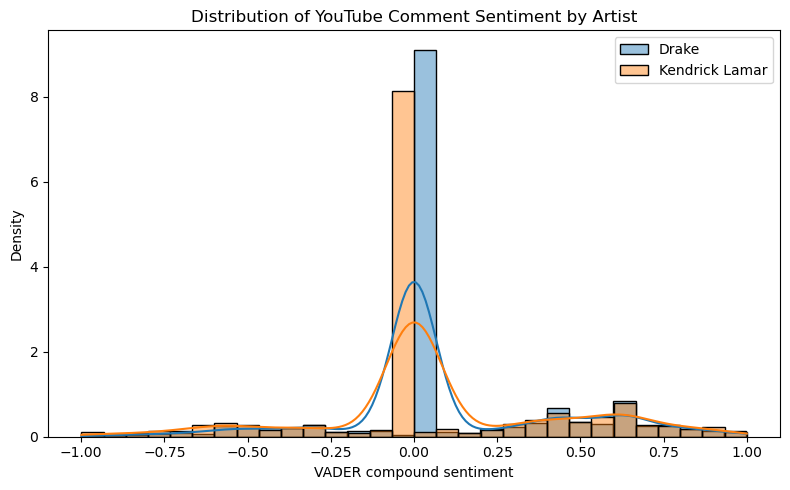

In [55]:
plt.figure(figsize=(8, 5))
# Drake
sb.histplot(data=commentsDF[commentsDF["artist_tag"] == "Drake"], x="sentiment", bins=30, kde=True, stat="density", alpha=0.45, label="Drake")

# Kendrick
sb.histplot(data=commentsDF[commentsDF["artist_tag"] == "Kendrick Lamar"], x="sentiment", bins=30, kde=True, stat="density", alpha=0.45, label="Kendrick Lamar")

plt.xlabel("VADER compound sentiment")
plt.ylabel("Density")
plt.title("Distribution of YouTube Comment Sentiment by Artist")
plt.legend()
plt.tight_layout()
plt.show()

The sentiment distributions for Drake and Kendrick Lamar are both heavily centered near zero. This indicates that most comments are neutral or only mildly positive. As shown earlier in the aggregate statistics, the mean sentiment for both artists sits just above zero. One interesting detail is the noticeable secondary bump around the 0.6 range. This suggests that a sizeable subset of comments are distinctly positive rather than just neutral, which may reflect moments where fans are reacting to a specific song, lyric, or cultural moment with stronger enthusiasm.

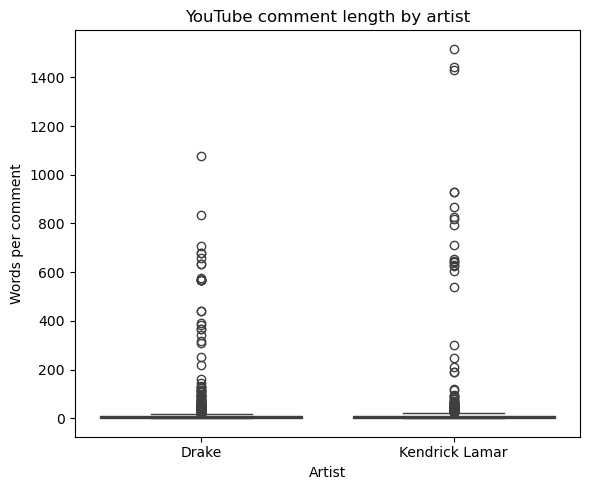

In [56]:
plt.figure(figsize=(6, 5))
sb.boxplot(data=commentsDF, x="artist_tag", y="word_count")
plt.xlabel("Artist")
plt.ylabel("Words per comment")
plt.title("YouTube comment length by artist")
plt.tight_layout()
plt.show()

Comments on Kendrick Lamar videos tend to be longer on average and show a wider spread in length. This supports the earlier summary table where his mean comment word count was higher. Fans appear to write more detailed or reflective responses to his songs, while Drake’s comment sections are shorter and more compact overall.

For my last visualization I was planning on connecting the two forms of analysis (lyrical + fan sentiment) but between API rate limits and a good amount of missing comment sections it feels more structured to keep them seperate.

Instead, I want to visualize the new lyrical components I calculated earlier throughout both artists careers. This will be interesting to compared with my temporal visualzation in project 1, looking at just rhyme density over time.

To avoid issues chaning the starting CSV, I will just import a new version from project 1 with just release year, artist, and song title.

In [57]:
yearDF = pd.read_csv("project2ReleaseYears.csv")
yearDF

,track_name,artist,release_year
0,tv off (feat. lefty gunplay),Kendrick Lamar,2024
1,HUMBLE.,Kendrick Lamar,2017
2,Swimming Pools (Drank),Kendrick Lamar,2012
3,LOVE. FEAT. ZACARI.,Kendrick Lamar,2017
4,PRIDE.,Kendrick Lamar,2017
5,squabble up,Kendrick Lamar,2024
6,Alright,Kendrick Lamar,2015
7,Money Trees,Kendrick Lamar,2012
8,DNA.,Kendrick Lamar,2017
9,peekaboo (feat. azchike),Kendrick Lamar,2024


In [58]:
songDF = songDF.rename(columns={"song_title": "track_name"})

In [59]:
mergedDF = songDF.merge(yearDF, on=["track_name", "artist"], how="inner") # line inner join

In [60]:
mergedDF.head()

,id,track_name,artist,album,rhyme_density,rhyme_scheme_variety,internal_rhyme_rate,avg_syllables_per_line,syllable_variance,stress_variability,word_count,complexity,release_year
0,1,tv off (feat. lefty gunplay),Kendrick Lamar,GNX,0.929504,None,None,11.415730,14.804696,0.442571,770,715.718016,2024
1,2,HUMBLE.,Kendrick Lamar,DAMN.,0.892562,None,None,10.507463,11.115616,0.288854,598,533.752066,2017
2,3,Swimming Pools (Drank),Kendrick Lamar,Swimming Pools (Drank),0.928654,None,None,10.928571,24.535714,0.416582,859,797.713464,2012
3,4,LOVE. FEAT. ZACARI.,Kendrick Lamar,DAMN.,0.947242,None,None,11.329268,23.415973,0.466321,488,462.254197,2017
4,5,PRIDE.,Kendrick Lamar,DAMN.,0.880626,None,None,10.754098,15.169041,0.497682,504,443.835616,2017


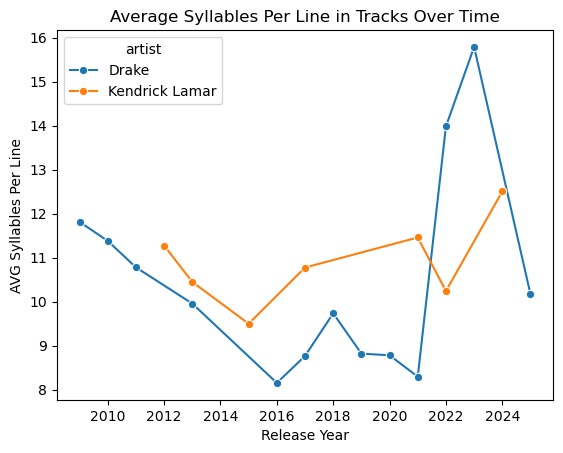

In [61]:
yearly = (mergedDF.groupby(["artist", "release_year"])["avg_syllables_per_line"].mean().reset_index())
sb.lineplot(data=yearly, x="release_year", y="avg_syllables_per_line", hue="artist", marker="o")
plt.title("Average Syllables Per Line in Tracks Over Time")
plt.xlabel("Release Year")
plt.ylabel("AVG Syllables Per Line")
plt.show()

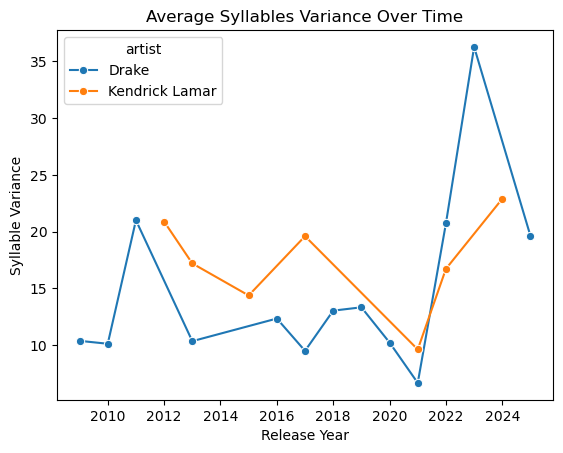

In [62]:
yearly = (mergedDF.groupby(["artist", "release_year"])["syllable_variance"].mean().reset_index())
sb.lineplot(data=yearly, x="release_year", y="syllable_variance", hue="artist", marker="o")
plt.title("Average Syllables Variance Over Time")
plt.xlabel("Release Year")
plt.ylabel("Syllable Variance")
plt.show()

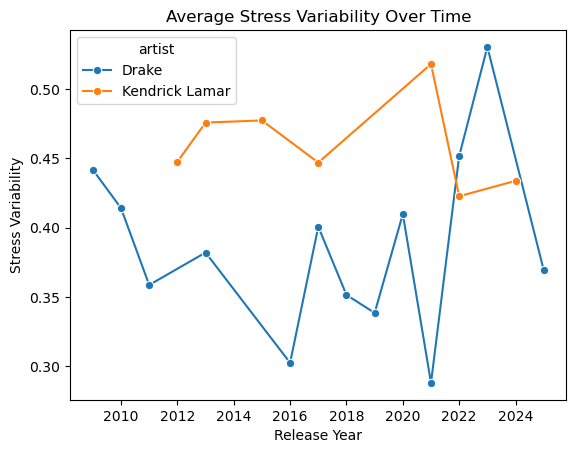

In [63]:
yearly = (mergedDF.groupby(["artist", "release_year"])["stress_variability"].mean().reset_index())
sb.lineplot(data=yearly, x="release_year", y="stress_variability", hue="artist", marker="o")
plt.title("Average Stress Variability Over Time")
plt.xlabel("Release Year")
plt.ylabel("Stress Variability")
plt.show()

Across all three metrics, Kendrick Lamar shows a consistently higher, (and more variable), linguistic complexity compared to Drake. Kendrick’s fluctuations across album cycles suggest experimentation with pacing, rhythm, and structural density. Drake’s trends are smoother and generally lower, which aligns with his emphasis on melody, delivery, and conversational language. The year-to-year variation also shows that neither artist is static. Kendrick’s spikes correspond to stylistic pivots between major releases, while Drake’s changes show shifts between pop-leaning and rap-leaning projects. These patterns help contextualize my earlier findings about comment behavior and complexity discussions in fan communities.